In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Defining Functions

In [9]:
# function to get the basic info about the dataset
def visual_data(df, hist_plot=True, corr_plot=True, multicollinear=True, corr_threshold=0.80):
    # basic info
    print("Data Information:")
    df.info()
    
    # first 10 rows
    print("\nFirst 10 rows:")
    print(df[:10])
    
    # duplicates
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = (duplicate_count / len(df)) * 100
    print(f"\nDuplicate Rows: {duplicate_count} ({duplicate_percentage:.2f}% of total rows)")

    # missing values
    missing_percentage = (df.isna().mean() * 100).round(2)
    total_missing = missing_percentage.sum()
    if total_missing > 0:
        print("\nMissing Values (%):")
        print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))
    else:
        print(f"\nMissing Values: 0.00%")
    
    # descriptive statistics for numeric columns
    print("\nDescriptive Statistics (Numerical):")
    print(df.describe().T.round(2))

    # descriptive statistics for categorical columns
    categorical_cols = df.select_dtypes(include=['object', 'category'])
    print("\nDescriptive Statistics (Categorical):")
    print(categorical_cols.describe().T)

    # histogram
    if hist_plot:
        df.hist(bins=20, color='blue', edgecolor='black', 
        grid=False,figsize=(12, 8))
        plt.tight_layout()
        plt.show()
    
    # correlation heatmap
    if corr_plot:
        numeric_cols = df.select_dtypes(include=['number'])
        plt.figure(figsize=(8, 6))
        corr_matrix = numeric_cols.corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
        fmt='.2f', linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.show()

    # multicollinearity
    if multicollinear and not numeric_cols.empty:
        print("\nChecking for Multicollinearity (Correlation Threshold > {:.2f}):".format(corr_threshold))
        high_corr_pairs = []
        corr_matrix = numeric_cols.corr().abs()  # Calculate correlation matrix for numeric columns only
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if corr_matrix.iloc[i, j] > corr_threshold:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        
        if high_corr_pairs:
            print("High correlation pairs found:")
            for pair in high_corr_pairs:
                print(f" - {pair[0]} and {pair[1]}: Correlation = {pair[2]:.2f}")
        else:
            print("No highly correlated pairs found.")

    return df

In [ ]:
# merging cocontiguous intervals for rows with the same 'Scientific/Common name'
def merge_contiguous_intervals(df): # continuos 

    merged_rows = []

    # start with the first row as the current interval
    current = df.iloc[0].copy()
    
    # iterate over the DataFrame from the second row onward
    for idx in range(1, len(df)):
        row = df.iloc[idx]
        
        # if the same species and the intervals are contiguous, merge them
        if (row['Common name'] == current['Common name'] and 
            row['Start (s)'] == current['End (s)']):
            # Extend the current interval's end time
            current['End (s)'] = row['End (s)']
        else:
            merged_rows.append(current)
            current = row.copy()
    

    merged_rows.append(current)
    
    merged_df = pd.DataFrame(merged_rows)
    
    # remove rows with a 3-second interval (i.e., where duration equals 3 seconds)
    merged_df = merged_df[(merged_df['End (s)'] - merged_df['Start (s)']) != 3]
    
    merged_df = merged_df.reset_index(drop=True)
    merged_df['Duration (s)'] = merged_df['End (s)'] - merged_df['Start (s)']
    return merged_df




In [11]:
# function to explore the dataset
# This function prints out unique values and their counts шт % for each column in the DataFrame.
def explore_dataset(df):
    for column in df.columns:
        print(f"Column: {column}")
        print("Unique values:")
        print(df[column].unique())
        print("\nValue counts:")
        print(round(df[column].value_counts(normalize=True) * 100, 2))
        print("-" * 40)

In [12]:
# function to calculate the accuracy of the dataset by calculating the mean confidence score
def accuracy(data):
    accuracy = round((data['Confidence'].mean()), 3) 
    accuracy_habitant = round((data[data['Habitant'] == 1]['Confidence'].mean()), 3) 
    accuracy__non_habitant = round((data[data['Habitant'] == 0]['Confidence'].mean()), 3)  

    print('Total accuracy:' , accuracy)
    print('Habitant accuracy:' , accuracy_habitant)
    print('Non Habitant accuracy:' , accuracy__non_habitant)
    print('_ ' *40)

In [13]:
# function to filter the dataset by groups
# based on the combination of 'ID', 'Month', 'Day', and 'Time', 'Start' and 'End' columns  
def filter_dataset_by_groups(df):
    # Create the temporary column 'Temp_ID' by concatenating the 6 columns as strings
    df['Temp_ID'] = (
        df['ID'].astype(str) + '_' +
        df['Month'].astype(str) + '_' +
        df['Day'].astype(str) + '_' +
        df['Time'].astype(str) + '_' +
        df['Start (s)'].astype(str) + '_' +
        df['End (s)'].astype(str)
    )
    
    # Filter the dataframe to include only groups with more than one row.
    # This will drop rows that are the only instance in their group.
    filtered_df = df.groupby('Temp_ID').filter(lambda group: len(group) > 1).reset_index(drop=True)
    
    return filtered_df

Preprocessing Data

In [14]:
data = pd.read_csv('data/data_20250330.csv')

In [15]:
# dropping redundant columns
data = data.drop(columns=['Unnamed: 0', 'Scientific name', 'Year'])

# adding a new column "Elevation_type" with low,medium, high values based on the observations automothes
data['Elevation_type'] = data['ID'].apply(lambda x: 'low' if x[:3] == 'psl'
                                   else ('medium' if x[:3] == 'psm'
                                        else ('high' if x[:3] == 'psh'
                                               else None)))

# saving the updated dataset for Looker/Tableau analysis
data.to_csv('data/data_20250330_looker.csv', index=False)

# grouping the dataset into different subsets
data_05 = data
data_06 = data[data['Confidence'] >= 0.6]
data_07 = data[data['Confidence'] >= 0.7]
data_08 = data[data['Confidence'] >= 0.8]
data_09 = data[data['Confidence'] >= 0.9]
data_10 = data[data['Confidence'] == 1.0]



Defining basic data for visualizations

In [ ]:
# define confidence levels and corresponding datasets
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9', '1.0']

# counts for values 0 and 1 for each dataset in the 'Habitant' column
counts_0 = [x['Habitant'].value_counts().get(0, 2) for x in [data_05, data_06, data_07, data_08, data_09, data_10]]
counts_1 = [x['Habitant'].value_counts().get(1, 2) for x in [data_05, data_06, data_07, data_08, data_09, data_10]] 

# oercentage for values 0 and 1 for each dataset in the 'Habitant' column
percentage_0 = [x['Habitant'].value_counts(normalize=True).get(0, 2) * 100 for x in [data_05, data_06, data_07, data_08, data_09, data_10]]
percentage_1 = [x['Habitant'].value_counts(normalize=True).get(1, 2) * 100 for x in [data_05, data_06, data_07, data_08, data_09, data_10]]

# Total observations counts for each dataset
total_counts = [len(data_05), len(data_06), len(data_07), len(data_08), len(data_09), len(data_10)]


Plotting Total, Habitant and Non Habitant observations by Confidence Levels

Confidence Levels: ['0.5', '0.6', '0.7', '0.8', '0.9', '1.0']
Counts of Total Observations: [206616, 160729, 122201, 86738, 50536, 55]
Counts of Non-Habitant (0): [31870, 20071, 12042, 6162, 2162, 2]
Counts of Habitant (1): [174746, 140658, 110159, 80576, 48374, 55]
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


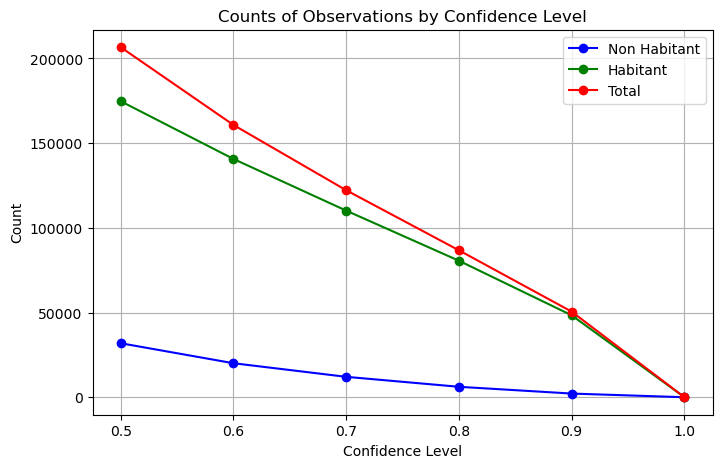

In [ ]:
# define x-axis positions
x = range(len(datasets))

print("Confidence Levels:", datasets)
print("Counts of Total Observations:", total_counts)
print("Counts of Non-Habitant (0):", counts_0)
print("Counts of Habitant (1):", counts_1)
print("_ " * 50)

plt.figure(figsize=(8, 5))
plt.plot(x, counts_0, marker='o', linestyle='-', color = 'blue', label='Non Habitant')
plt.plot(x, counts_1, marker='o', linestyle='-', color = 'green', label='Habitant')
plt.plot(x, total_counts, marker='o', linestyle='-', color = 'red', label='Total')

plt.xticks(x, datasets)
plt.xlabel("Confidence Level")
plt.ylabel("Count")
plt.title("Counts of Observations by Confidence Level")
plt.legend()
plt.grid(True)


Plotting Rate of Change ("Speed") and Change of Speed ("Acceleration")

First Derivative (Rate of Change) for Non Habitant: [-117990.  -80290.  -58800.  -40000.  -21600.]
First Derivative (Rate of Change) for Habitant: [-340880. -304990. -295830. -322020. -483190.]
First Derivative (Rate of Change) for Total: [-458870. -385280. -354630. -362020. -504810.]
Second Derivative (Change of Speed) for Non Habitant: [377000. 214900. 188000. 184000.]
Second Derivative (Change of Speed) for Habitant: [  358900.    91600.  -261900. -1611700.]
Second Derivative (Change of Speed) for Total: [  735900.   306500.   -73900. -1427900.]
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


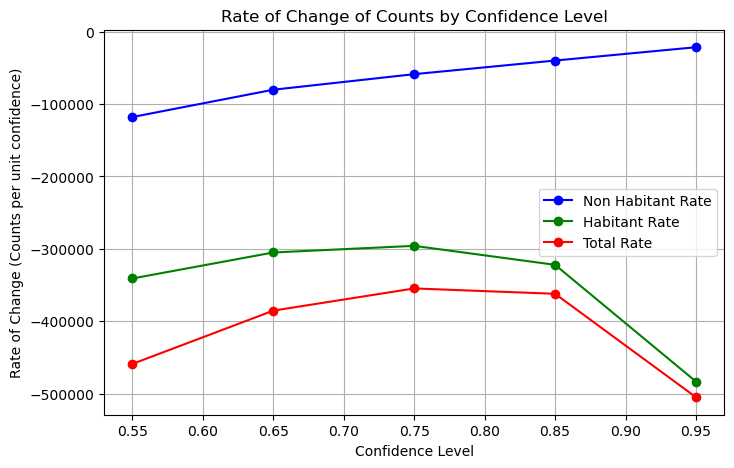

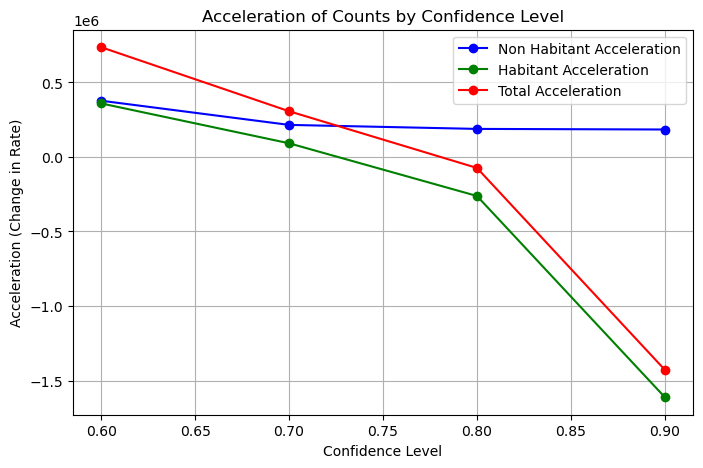

In [ ]:
# convert confidence levels that were defined as strings to floats
datasets_np = np.array(datasets, dtype=float)

# convert counts lists to NumPy arrays
counts_0_np = np.array(counts_0)
counts_1_np = np.array(counts_1)
total_counts_np = np.array(total_counts)

# first Derivative: Rate of Change ("Speed")
counts_0_change = np.diff(counts_0_np) / np.diff(datasets_np)
counts_1_change = np.diff(counts_1_np) / np.diff(datasets_np)
total_counts_change  = np.diff(total_counts_np) / np.diff(datasets_np)

print("First Derivative (Rate of Change) for Non Habitant:", counts_0_change)
print("First Derivative (Rate of Change) for Habitant:", counts_1_change)
print("First Derivative (Rate of Change) for Total:", total_counts_change)

# second Derivative: Change of Speed ("Acceleration")
# Use datasets[:-1] since the first derivative arrays have one less element
counts_0_accel = np.diff(counts_0_change) / np.diff(datasets_np[:-1])
counts_1_accel = np.diff(counts_1_change) / np.diff(datasets_np[:-1])
total_counts_accel  = np.diff(total_counts_change) / np.diff(datasets_np[:-1])

print("Second Derivative (Change of Speed) for Non Habitant:", counts_0_accel)
print("Second Derivative (Change of Speed) for Habitant:", counts_1_accel)
print("Second Derivative (Change of Speed) for Total:", total_counts_accel)
print("_ " * 50)

# plotting the First Derivative (Rate of Change) 
# Calculate midpoints of the confidence intervals for plotting the first derivative.
x_midpoints = datasets_np[:-1] + np.diff(datasets_np) / 2

plt.figure(figsize=(8, 5))
plt.plot(x_midpoints, counts_0_change, marker='o', linestyle='-', color='blue', label='Non Habitant Rate')
plt.plot(x_midpoints, counts_1_change, marker='o', linestyle='-', color='green', label='Habitant Rate')
plt.plot(x_midpoints, total_counts_change, marker='o', linestyle='-', color='red', label='Total Rate')
plt.xlabel("Confidence Level")
plt.ylabel("Rate of Change (Counts per unit confidence)")
plt.title("Rate of Change of Counts by Confidence Level")
plt.legend()
plt.grid(True)
plt.show()

# plotting the Second Derivative (Acceleration)
# Compute midpoints for the second derivative intervals.
x_midpoints2 = x_midpoints[:-1] + np.diff(x_midpoints) / 2

plt.figure(figsize=(8, 5))
plt.plot(x_midpoints2, counts_0_accel, marker='o', linestyle='-', color='blue', label='Non Habitant Acceleration')
plt.plot(x_midpoints2, counts_1_accel, marker='o', linestyle='-', color='green', label='Habitant Acceleration')
plt.plot(x_midpoints2, total_counts_accel, marker='o', linestyle='-', color='red', label='Total Acceleration')
plt.xlabel("Confidence Level")
plt.ylabel("Acceleration (Change in Rate)")
plt.title("Acceleration of Counts by Confidence Level")
plt.legend()
plt.grid(True)
plt.show()


- A significant drop of Total and Habitant observations past 0.85 confidence level
- A small increase of confidence level after 0.8 causes a rapid drop in Total and Habitant predictions

Comparing Dataset Accuracy (Mean) with Observations

Overall Accuracy: [0.754, 0.813, 0.865, 0.912, 0.957, 1.0]
Counts of Total Observations: [206616, 160729, 122201, 86738, 50536, 55]
Counts of Non-Habitant (0): [31870, 20071, 12042, 6162, 2162, 2]
Counts of Habitant (1): [174746, 140658, 110159, 80576, 48374, 55]
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


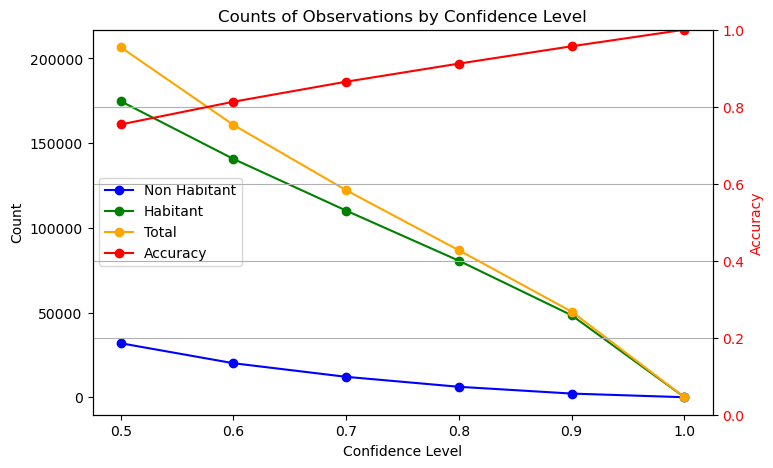

In [ ]:
# compute average accuracies for each dataset
accuracies = [
    data_05['Confidence'].mean().round(3),
    data_06['Confidence'].mean().round(3),
    data_07['Confidence'].mean().round(3),
    data_08['Confidence'].mean().round(3),
    data_09['Confidence'].mean().round(3),
    data_10['Confidence'].mean()  
]


print("Overall Accuracy:", accuracies)
print("Counts of Total Observations:", total_counts)
print("Counts of Non-Habitant (0):", counts_0)
print("Counts of Habitant (1):", counts_1)
print("_ " * 50)

# Plotting the counts and accuracies
x = range(len(datasets))

# Create the primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot counts on the primary y-axis
ax1.plot(x, counts_0, marker='o', linestyle='-', color='blue', label='Non Habitant')
ax1.plot(x, counts_1, marker='o', linestyle='-', color='green', label='Habitant')
ax1.plot(x, total_counts, marker='o', linestyle='-', color='orange', label='Total')
ax1.set_xlabel("Confidence Level")
ax1.set_ylabel("Count", color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a secondary y-axis for accuracy
ax2 = ax1.twinx()
ax2.plot(x, accuracies, marker='o', linestyle='-', color='red', label='Accuracy')
ax2.set_ylabel("Accuracy", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)

# Set x-axis labels and plot title
plt.xticks(x, datasets)
plt.title("Counts of Observations by Confidence Level")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.grid(True)
plt.show()


Plotting Accuracy for Habitant, Non-habitant and Total Observations

Overall Accuracies: [0.754, 0.813, 0.865, 0.912, 0.957, 1.0]
Habitant Accuracies: [0.769, 0.823, 0.871, 0.915, 0.957, 1.0]
Non-Habitant Accuracies: [0.673, 0.748, 0.815, 0.879, 0.94, nan]
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


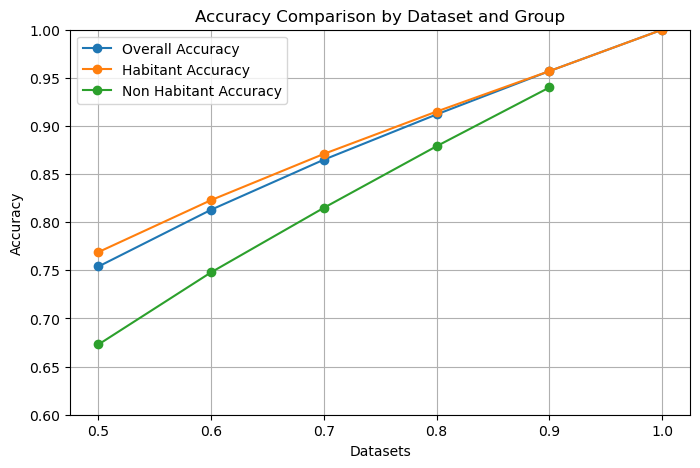

In [47]:
# accuracies for each dataset
accuracies = [
    data_05['Confidence'].mean().round(3),
    data_06['Confidence'].mean().round(3),
    data_07['Confidence'].mean().round(3),
    data_08['Confidence'].mean().round(3),
    data_09['Confidence'].mean().round(3),
    data_10['Confidence'].mean()  # Assuming data_10 is defined
]

# habitant accuracies for each dataset
habitant_accuracies = [
    data_05[data_05['Habitant'] == 1]['Confidence'].mean().round(3),
    data_06[data_06['Habitant'] == 1]['Confidence'].mean().round(3),
    data_07[data_07['Habitant'] == 1]['Confidence'].mean().round(3),
    data_08[data_08['Habitant'] == 1]['Confidence'].mean().round(3),
    data_09[data_09['Habitant'] == 1]['Confidence'].mean().round(3),
    data_10[data_10['Habitant'] == 1]['Confidence'].mean() 
]

# non-habitant accuracies for each dataset
non_habitant_accuracies = [
    data_05[data_05['Habitant'] == 0]['Confidence'].mean().round(3),
    data_06[data_06['Habitant'] == 0]['Confidence'].mean().round(3),
    data_07[data_07['Habitant'] == 0]['Confidence'].mean().round(3),
    data_08[data_08['Habitant'] == 0]['Confidence'].mean().round(3),
    data_09[data_09['Habitant'] == 0]['Confidence'].mean().round(3),
    data_10[data_10['Habitant'] == 0]['Confidence'].mean()
]

x = range(len(datasets))

print("Overall Accuracies:", accuracies)
print("Habitant Accuracies:", habitant_accuracies)
print("Non-Habitant Accuracies:", non_habitant_accuracies)
print("_ " * 50)

plt.figure(figsize=(8, 5))

# Plot overall accuracies
plt.plot(x, accuracies, marker='o', linestyle='-', label='Overall Accuracy')
# Plot habitant accuracies
plt.plot(x, habitant_accuracies, marker='o', linestyle='-', label='Habitant Accuracy')
# Plot non-habitant accuracies
plt.plot(x, non_habitant_accuracies, marker='o', linestyle='-', label='Non Habitant Accuracy')

plt.xticks(x, datasets)
plt.xlabel('Datasets')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison by Dataset and Group')
plt.ylim(0.6, 1)  # y-axis from 0.6 to 1
plt.legend()
plt.grid(True)
plt.show()


- At confidence level 0.9, Total and Habitant means are both equal to 0.957


Exploratory Data Analysis

In [22]:
df = data_08

In [23]:
df = df[df['Habitant'] == 1].reset_index(drop=True)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80576 entries, 0 to 80575
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Start (s)       80576 non-null  float64
 1   End (s)         80576 non-null  float64
 2   Common name     80576 non-null  object 
 3   Confidence      80576 non-null  float64
 4   ID              80576 non-null  object 
 5   Month           80576 non-null  int64  
 6   Day             80576 non-null  int64  
 7   Time            80576 non-null  int64  
 8   Latitude        80576 non-null  float64
 9   Longitude       80576 non-null  float64
 10  Elevation       80576 non-null  int64  
 11  Habitant        80576 non-null  int64  
 12  Elevation_type  80576 non-null  object 
dtypes: float64(5), int64(5), object(3)
memory usage: 8.0+ MB

First 10 rows:
   Start (s)  End (s)     Common name  Confidence     ID  Month  Day  Time  \
0        6.0      9.0  hume's warbler     

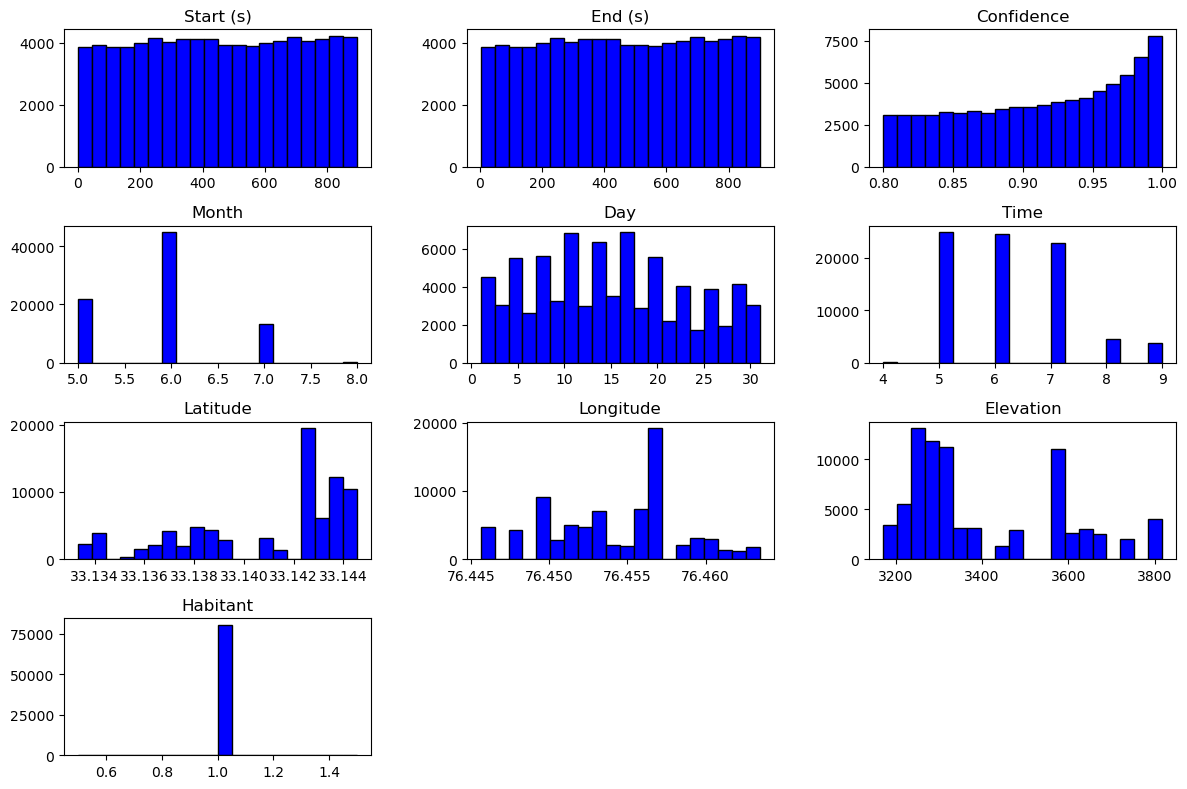

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


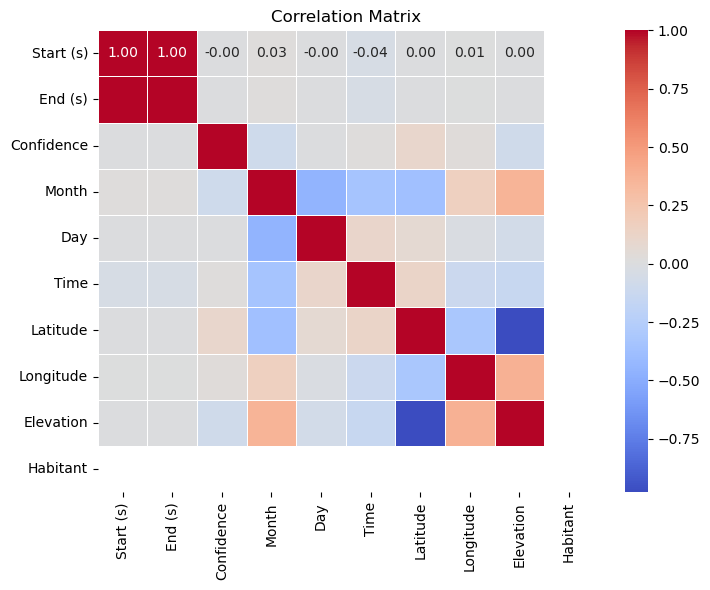


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Elevation_type
0,6.0,9.0,hume's warbler,0.8799,psh10,6,4,6,33.135140,76.463139,3664,1,high
1,27.0,30.0,hume's warbler,0.8052,psh10,6,4,6,33.135140,76.463139,3664,1,high
2,39.0,42.0,hume's warbler,0.8985,psh10,6,4,6,33.135140,76.463139,3664,1,high
3,60.0,63.0,hume's warbler,0.8016,psh10,6,4,6,33.135140,76.463139,3664,1,high
4,69.0,72.0,hume's warbler,0.8453,psh10,6,4,6,33.135140,76.463139,3664,1,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80571,468.0,471.0,white-bellied redstart,0.8050,psm9,7,26,5,33.141258,76.461078,3438,1,medium
80572,555.0,558.0,white-bellied redstart,0.9244,psm9,7,26,5,33.141258,76.461078,3438,1,medium
80573,810.0,813.0,hume's warbler,0.9044,psm9,7,26,6,33.141258,76.461078,3438,1,medium
80574,54.0,57.0,variegated laughingthrush,0.8373,psm9,7,26,7,33.141258,76.461078,3438,1,medium


In [24]:
visual_data(df)

In [25]:
explore_dataset(df)

Column: Start (s)
Unique values:
[  6.  27.  39.  60.  69.  75.  93. 135. 153. 159. 165. 213. 219. 225.
 231. 240. 255. 273. 288. 306. 330. 351. 357. 378. 387. 411. 414. 456.
 486. 507. 534. 543. 546. 558. 582. 597. 606. 615. 621. 627. 642. 648.
 663. 672. 681. 690. 699. 705. 711. 720. 729. 738. 744. 753. 765. 774.
 786. 795. 804. 813. 819. 828. 837. 846. 855. 861. 867. 876.  81. 234.
 360. 495. 624. 645. 675. 696. 726. 762. 768. 777. 783. 789. 825. 831.
  21.  48.  54. 192. 198. 285. 297. 429. 510. 600. 885.  51. 195. 201.
 216. 222. 228. 249. 420. 432. 501. 603. 183. 210. 261. 270. 834. 849.
 870. 879.  63.  84. 489. 531.  12. 147. 156. 279. 342. 348. 369. 375.
 435. 447. 516. 612. 636. 654. 660. 678. 723. 741.   9.  78. 111. 891.
 702. 105. 108. 177. 264. 438. 567.  66. 426. 498. 525. 792. 801. 816.
 873.  15.  90. 168. 333. 402. 519. 630.  42.  45.  57. 120. 309. 579.
 687. 138. 747. 315. 324. 327. 585. 393. 204. 207. 708. 780. 864. 882.
 897. 129. 441. 462. 465. 468. 471. 474. 477

- Total Observations: 102,968
- 34 bird species were observed, with Western Crowned Warbler, Hume's Warbler, Variegated Laughingthrush, and Greenish Warbler making up nearly 82% of all the observations.
- Most common bird: Western Crowned Warbler (41.1% of all observations), followed by Hume's Warbler at 19.1%.
- Most observations occurred in June between 5 AM and 7 AM, at low elevations of 3200-3600 feet. The latitude ranged from 33.142 to 33.144, within 0.14 miles, and the longitude from 76.450 to 76.457, within 0.4 miles.

In [26]:
df_hume = df[df['Common name'] == "hume's warbler"]

In [ ]:
visual_data(df_hume)

In [28]:
explore_dataset(df_hume)

Column: Start (s)
Unique values:
[  6.  27.  39.  60.  69.  75.  93. 135. 153. 159. 165. 213. 219. 225.
 231. 240. 255. 273. 288. 306. 330. 351. 357. 486. 507. 534. 543. 546.
 558. 582. 597. 606. 615. 621. 627. 642. 648. 663. 672. 681. 690. 699.
 705. 711. 720. 729. 738. 744. 753. 765. 774. 786. 795. 804. 813. 819.
 828. 837. 846. 855. 861. 867. 876.  81. 495. 624. 645. 675. 696. 726.
 762. 768. 777. 783. 789. 825. 831. 501. 342. 348. 375.  78. 111. 792.
 801. 315. 327. 585.  84. 417. 435. 441. 444. 447. 450. 453. 456. 459.
 462. 468. 474. 750. 414. 810. 843. 849.  45. 300. 426. 603. 780. 138.
 144. 147. 258. 660. 636. 654. 714. 723. 732. 612. 189. 264. 282. 294.
 567. 594. 759. 834. 852. 873. 207. 618. 702.  33.  42.  57. 201. 555.
 564. 588. 591. 666. 747. 894.  24. 114. 132. 162. 174. 180. 183. 186.
 198. 228. 261. 267. 678. 756. 822. 864.  66. 537.  51.  63.  72.  90.
  99. 108. 123. 141. 195. 204. 222. 309. 336. 345. 363. 381. 390. 402.
 693. 735. 600. 369. 399. 150. 156. 192. 498

- Target specie is observed 19,697 times.
- Hume's Warbler is primarily observed at mid elevations, accounting for nearly 51% of all observations.
- It tends to sing most frequently between 6 AM and 7 AM, with slightly fewer observations at 5 AM.
- It is most commonly found at elevations between 3,475 and 3,650 feet, with a latitude range of 33.138 to 33.140 (within 0.14 miles) and a longitude range of 76.449 to 76.452 (within 0.17 miles).

Exploring the songs ( continuos intervals >= 3 sec of the same specie)

In [29]:
df_song = merge_contiguous_intervals(df)

In [30]:
df_song.to_csv('data/songs.csv')

In [ ]:
visual_data(df_song)

In [32]:
explore_dataset(df_song)

Column: Start (s)
Unique values:
[411. 543. 213. 531. 432. 720. 105.  42. 204. 834. 882. 462. 501. 510.
 555. 597. 609.  54.  66. 585. 789. 822. 129. 345. 513. 195. 441. 813.
 507.   6.  18.  27. 759.  12.  21.  51.  60.  69.  90. 120. 147. 162.
 231. 267. 387.  75. 315. 324. 795. 843. 414. 429. 438. 876. 891. 477.
 528. 564. 588. 606. 639. 657. 666. 693. 714. 885.   9.  45. 336. 366.
 378. 408. 852.   3.  78. 138. 159. 732. 222. 246. 417. 567. 582. 675.
 318. 456. 111. 186.   0. 207. 240. 561. 618. 144. 699. 708. 744. 198.
 255. 288. 363. 846.  93. 102. 156. 180. 258. 540. 558. 570. 621. 756.
 783.  84. 594. 177. 831. 423. 696. 711. 141. 150. 216. 228. 489. 660.
 753. 870. 354. 390. 468. 384. 396. 435. 444. 480. 576. 786. 486. 237.
 735.  39. 645. 219.  24. 117. 135. 747. 858. 630. 678. 774. 153. 189.
 330. 723. 801. 879.  57. 792. 276. 360. 768.  15.  33. 339. 426. 420.
  99. 303. 600. 627. 171. 516. 126. 495. 504. 522. 591. 669. 729.  30.
  63.  72.  81. 351. 519. 690. 807. 780. 741

In [33]:
df_champs = df_song[df_song['Duration (s)'] > 99]
df_champs

,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Elevation_type,Duration (s)
1807,246.0,357.0,western crowned warbler,0.8150,psl10,5,30,5,33.143827,76.457181,3300,1,low,111.0
2165,444.0,573.0,western crowned warbler,0.9636,psl10,6,7,5,33.143827,76.457181,3300,1,low,129.0
2168,627.0,768.0,western crowned warbler,0.9513,psl10,6,7,5,33.143827,76.457181,3300,1,low,141.0
5071,249.0,351.0,western crowned warbler,0.9470,psl3,5,16,9,33.142799,76.452975,3289,1,low,102.0
8549,606.0,717.0,western crowned warbler,0.9893,psl9,6,27,7,33.142472,76.459610,3341,1,low,111.0


In [ ]:
df_song_wcw = df_song[(df_song['Common name'] == "western crowned warbler") & (df_song['ID'] == 'psl10')]
visual_data(df_song_wcw)


In [35]:
df_song_hume = df_song[df_song['Common name'] == "hume's warbler"]

In [ ]:
visual_data(df_song_hume)

In [37]:
explore_dataset(df_song_hume)   

Column: Start (s)
Unique values:
[543. 441. 144. 588. 180. 258. 354. 378. 390. 408. 417. 468.  75. 102.
 267. 360. 324. 171. 480. 516. 195. 510. 519. 531. 591. 678. 690. 708.
 807.  24. 117. 768. 780. 177. 159. 192. 555. 651. 291. 330. 198. 210.
  90. 138. 201. 216. 228. 351. 372. 669.  48.  57. 486. 525. 864. 579.
 363. 384. 774. 873. 570. 366. 375. 342.  15. 165. 786. 405. 426. 462.
 477. 492. 513.  45.  78. 495. 747. 756. 765.  87. 537. 561. 705.  99.
 450. 483. 255. 282. 615. 711. 726. 321. 648. 717. 237. 249. 753. 771.
 801. 231. 243. 432. 141. 852. 501. 186. 246. 207. 219. 645. 675. 834.
 843. 240. 672. 633. 816. 858. 891. 402. 252. 279. 567. 612. 837.  84.
 114. 222. 552. 759. 840. 684. 750. 540. 549. 306. 318. 606.   0. 132.
 777. 798. 294. 792. 261. 681. 636.  36. 357. 585. 621. 387. 381. 129.
 489.  72. 420. 729. 828. 666. 630. 126. 735. 276. 339. 396. 438. 474.
 831. 723. 714. 810. 234. 423. 627. 618. 654. 693. 732. 888. 861.   6.
 762. 789.  69. 819.   3. 315. 336.  12. 213

- A total of 15,432 observations were made where a bird was singing continuously for more than 3 seconds.
- The average duration of a continuous song is approximately 9 seconds.
- The "champion" for song duration is the Western Crowned Warbler, observed at low elevation.  
The longest songs were recorded at a specific location PSL10 with a latitude of 33.143827 and longitude of 76.457181, at an elevation of 3300 feet.  
This bird was observed at this spot 1,356 times (almost 9% of all bird observations), with 7 instances of singing for more than 108 seconds, reaching a maximum of 210 seconds (3.5 minutes).
- Hume's Warbler was observed 2,720 times (17.8% of total observations), with an average continuous song duration of 8.5 seconds, slightly below the overall average.
- 64% of its longer songs lasted 6 seconds, with a maximum duration of 69 seconds.
- Over 32% of Hume's Warbler's songs were recorded at elevations of 3570-3572 meters.

Explore who is signing 3 sec before and after Hume's Warbler

Explore which birds are interacting within the same 3-second audio chunk

In [38]:
df_group = filter_dataset_by_groups(df)

In [ ]:
visual_data(df_group) 

In [40]:
explore_dataset(df_group)

Column: Start (s)
Unique values:
[414. 486. 132. 264. 201.  24. 153. 198. 231. 441. 156.  99. 684. 720.
 396. 714.   3. 681. 270. 276. 288. 294. 303. 312. 363. 450. 471. 489.
 315. 327. 339. 357. 384. 420. 429.  84. 573. 435.  18.  81. 324. 423.
 594.  42.  93. 141. 483. 504. 543. 567.  36. 858. 888. 372. 498. 507.
 540. 603. 609. 873.  63. 831. 837.  15.  21.  33.  45.  72. 102. 117.
 147. 219. 261. 612. 669. 696. 717. 894.  27. 732. 648. 501. 642. 744.
 816. 171. 195. 207. 228.  39. 576. 291. 756. 306. 522. 285. 723. 735.
 105. 135. 165. 216. 513.  75. 252. 690. 702. 708. 666. 249. 204. 615.
 711. 789.  87. 192.  78. 585. 600.   0. 453. 255. 273. 747. 528. 822.
 762. 579. 510. 705. 750. 870. 663. 411. 546. 849. 348. 318. 867. 564.
 330. 606. 795. 480. 786. 108. 813. 882. 876. 444. 462. 843. 819. 177.
  69. 417. 351. 213. 150. 657. 240. 807. 840. 846. 879. 885. 891. 570.
 741. 438. 174. 531. 810. 678. 852. 618. 297. 459. 768. 495. 111. 168.
 492.  60. 321. 390. 402. 447. 474. 477. 114

In [41]:
df_group['Common name'].value_counts(normalize=True).round(2)*100   

Common name
hume's warbler                      30.0
himalayan bluetail                  25.0
western crowned warbler             10.0
variegated laughingthrush            8.0
large-billed leaf warbler            6.0
indian blue robin                    6.0
tytler's leaf warbler                4.0
greenish warbler                     3.0
white-bellied redstart               2.0
olive-backed pipit                   2.0
slaty-blue flycatcher                1.0
buff-barred warbler                  1.0
blue-fronted redstart                0.0
himalayan monal                      0.0
common rosefinch                     0.0
rufous-breasted accentor             0.0
coal tit                             0.0
rufous-naped tit                     0.0
rock bunting                         0.0
tickell's leaf warbler               0.0
lemon-rumped warbler                 0.0
himalayan white-browed rosefinch     0.0
eurasian kestrel                     0.0
Name: proportion, dtype: float64

In [42]:
pairs = df_group.groupby('Temp_ID')['Common name'].apply(lambda x: tuple(sorted(x.unique())))


In [43]:
pairs.value_counts()

Common name
(himalayan bluetail, hume's warbler)                    168
(indian blue robin, large-billed leaf warbler)           39
(variegated laughingthrush, western crowned warbler)     27
(tytler's leaf warbler, western crowned warbler)         22
(greenish warbler, hume's warbler)                       20
(olive-backed pipit, variegated laughingthrush)          12
(western crowned warbler, white-bellied redstart)        11
(hume's warbler, variegated laughingthrush)              11
(slaty-blue flycatcher, variegated laughingthrush)        4
(buff-barred warbler, hume's warbler)                     4
(tytler's leaf warbler, white-bellied redstart)           4
(hume's warbler, western crowned warbler)                 4
(himalayan monal, hume's warbler)                         3
(buff-barred warbler, himalayan bluetail)                 3
(blue-fronted redstart, slaty-blue flycatcher)            2
(hume's warbler, slaty-blue flycatcher)                   2
(rufous-naped tit, western c

In [44]:
# Count the frequency of each unique pair
pair_counts = pairs.value_counts()
pairs_hume = pair_counts[[ "hume's warbler" in combo for combo in pair_counts.index ]] # Hume's warbler pairs
print(pairs_hume)

Common name
(himalayan bluetail, hume's warbler)           168
(greenish warbler, hume's warbler)              20
(hume's warbler, variegated laughingthrush)     11
(buff-barred warbler, hume's warbler)            4
(hume's warbler, western crowned warbler)        4
(himalayan monal, hume's warbler)                3
(hume's warbler, slaty-blue flycatcher)          2
(hume's warbler, tickell's leaf warbler)         1
(common rosefinch, hume's warbler)               1
(hume's warbler, large-billed leaf warbler)      1
Name: count, dtype: int64


- intercation- time correlation_ explore it within time change
- 